# Tutorial 5: Convulution Neural Network (CNN)

### Cell 1: Import Libraries

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

### Cell 2: Load and Preprocess Dataset

In [2]:
# Step 2: Load and Preprocess the CIFAR-10 Dataset 
# Normalizing pixel values to help model converge ]
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)

testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=False)

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck'] 

100.0%


### Cell 3: Visualize Training Data

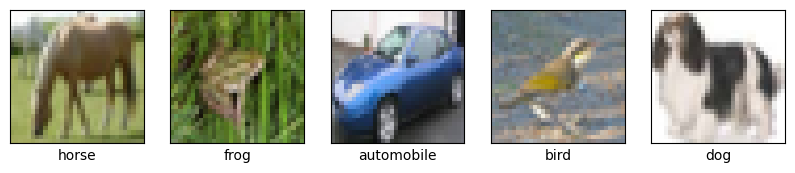

In [3]:
# Step 3: Visualize Some Data 
def imshow(img):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

# Get some random training images
dataiter = iter(trainloader)
images, labels = next(dataiter)

# show images
plt.figure(figsize=(10, 4))
for i in range(5): # [cite: 29]
    plt.subplot(1, 5, i + 1)
    plt.xticks([]) # [cite: 31, 33]
    plt.yticks([]) # [cite: 32, 34]
    plt.grid(False) # [cite: 35, 36]
    img = images[i] / 2 + 0.5
    plt.imshow(np.transpose(img.numpy(), (1, 2, 0)))
    plt.xlabel(class_names[labels[i]]) 
plt.show()

### Cell 4: Define the CNN Model

In [5]:
# Step 4: Build the Convolutional Neural Network 
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        # 1st Conv Layer: 3x3 kernel, 32 filters 
        self.conv1 = nn.Conv2d(3, 32, 3) 
        # Max Pooling: 2x2 pool size 
        self.pool = nn.MaxPool2d(2, 2)
        # 2nd Conv Layer: 64 filters 
        self.conv2 = nn.Conv2d(32, 64, 3)
        # 3rd Conv Layer: 64 filters 
        self.conv3 = nn.Conv2d(64, 64, 3)
        
        # Flattening and Fully Connected Layers 
        self.fc1 = nn.Linear(64 * 4 * 4, 64) # Dense layer 64 neurons 
        self.fc2 = nn.Linear(64, 10) # Output layer 10 neurons 

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = F.relu(self.conv3(x))
        x = x.view(-1, 64 * 4 * 4) # Flatten 
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model = Net()

### Cell 5: Compile and Train the Model

In [6]:
# Step 5: Compile the Model 
criterion = nn.CrossEntropyLoss() # Standard for classification 
optimizer = optim.Adam(model.parameters(), lr=0.001) # Adam optiizer 

# Step 6: Train the Model for 10 epochs 
history = {'loss': [], 'accuracy': []}

for epoch in range(10): 
    running_loss = 0.0
    correct = 0
    total = 0
    
    model.train()
    for inputs, labels in trainloader:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward() # Backpropagation 
        optimizer.step() # Update weights
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
    epoch_acc = 100 * correct / total
    history['loss'].append(running_loss/len(trainloader))
    history['accuracy'].append(epoch_acc)
    print(f'Epoch {epoch+1}, Loss: {running_loss/len(trainloader):.4f}, Accuracy: {epoch_acc:.2f}%')

Epoch 1, Loss: 1.5440, Accuracy: 43.55%
Epoch 2, Loss: 1.2050, Accuracy: 57.06%
Epoch 3, Loss: 1.0359, Accuracy: 63.52%
Epoch 4, Loss: 0.9233, Accuracy: 67.69%
Epoch 5, Loss: 0.8400, Accuracy: 70.36%
Epoch 6, Loss: 0.7732, Accuracy: 72.94%
Epoch 7, Loss: 0.7166, Accuracy: 75.00%
Epoch 8, Loss: 0.6668, Accuracy: 76.71%
Epoch 9, Loss: 0.6231, Accuracy: 78.23%
Epoch 10, Loss: 0.5859, Accuracy: 79.59%


### Cell 6: Performance Visualization & Tasks

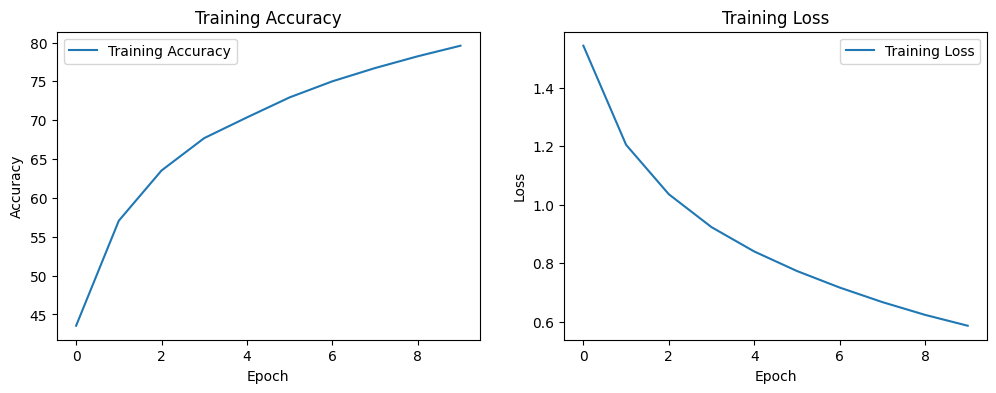

In [7]:
# Step 8: Plot Training Accuracy/Loss 
plt.figure(figsize=(12, 4)) 

# Accuracy plot 
plt.subplot(1, 2, 1)
plt.plot(history['accuracy'], label='Training Accuracy')
plt.title('Training Accuracy')
plt.xlabel('Epoch') 
plt.ylabel('Accuracy') 
plt.legend()

# Loss plot 
plt.subplot(1, 2, 2)
plt.plot(history['loss'], label='Training Loss')
plt.title('Training Loss')
plt.xlabel('Epoch') 
plt.ylabel('Loss') 
plt.legend()

plt.show()